In [5]:
import zipfile

zip_path = "archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("crop_dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [7]:
import os

for root, dirs, files in os.walk("crop_dataset"):
    print(root)
    print(files)

crop_dataset
['pesticides.csv', 'rainfall.csv', 'temp.csv', 'yield.csv', 'yield_df.csv']


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [13]:
data = pd.read_csv("crop_dataset/yield_df.csv")

In [15]:
data.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [17]:
print(data.columns)

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')


In [19]:
data = data.drop('Unnamed: 0', axis=1)

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['Area'] = encoder.fit_transform(data['Area'])

data['Item'] = encoder.fit_transform(data['Item'])

In [23]:
X = data.drop('hg/ha_yield', axis=1)

y = data['hg/ha_yield']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("R2 Score:", r2)

Mean Absolute Error: 3752.47717472119
R2 Score: 0.9857081655966298


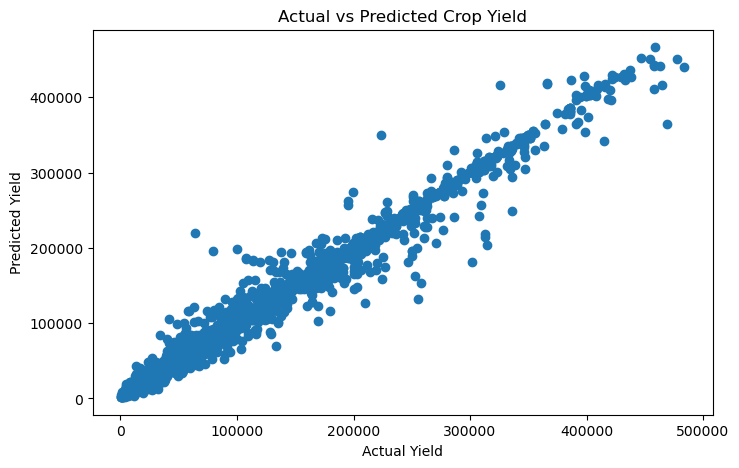

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Crop Yield")

plt.show()

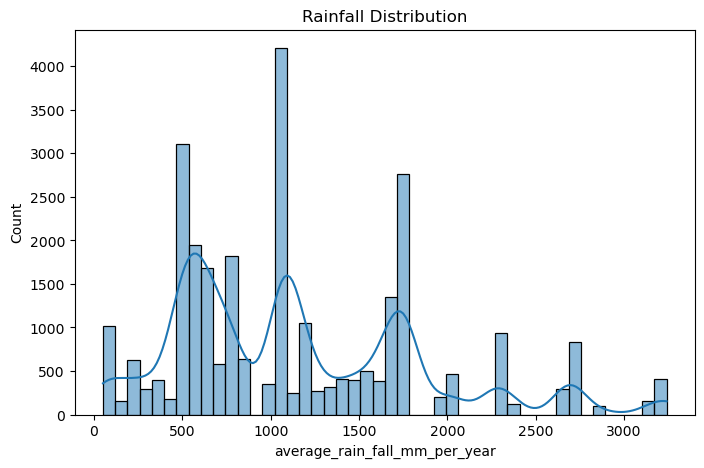

In [35]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    data['average_rain_fall_mm_per_year'],
    kde=True
)

plt.title("Rainfall Distribution")

plt.show()

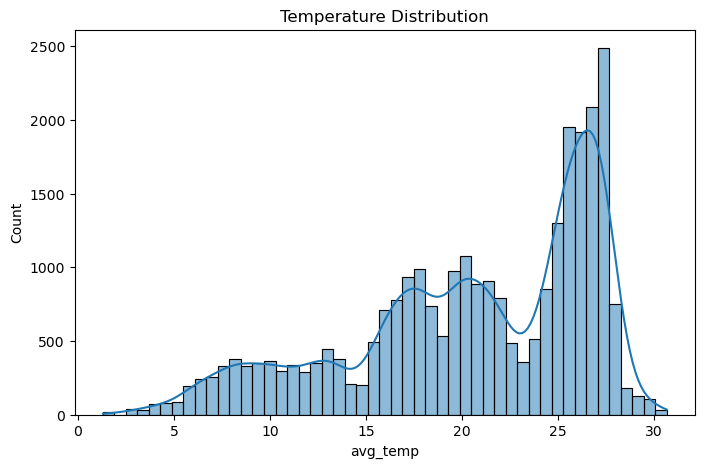

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    data['avg_temp'],
    kde=True
)

plt.title("Temperature Distribution")

plt.show()

In [39]:
importance = model.feature_importances_

feature_names = X.columns

feature_data = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_data = feature_data.sort_values(
    by='Importance',
    ascending=False
)

print(feature_data)

                         Feature  Importance
1                           Item    0.608696
4              pesticides_tonnes    0.110261
5                       avg_temp    0.108493
3  average_rain_fall_mm_per_year    0.086523
0                           Area    0.055021
2                           Year    0.031006


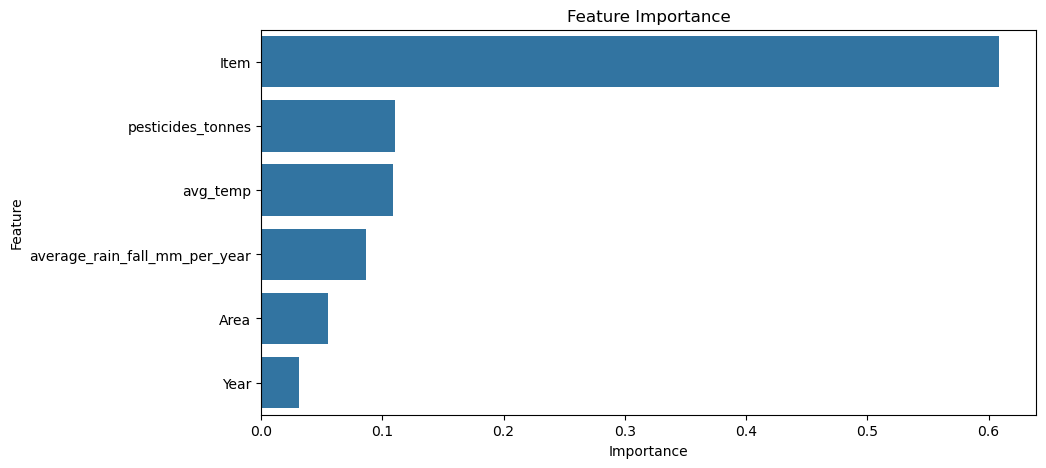

In [41]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_data
)

plt.title("Feature Importance")

plt.show()

In [43]:
sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print("Predicted Crop Yield:", prediction[0])

Predicted Crop Yield: 71353.31
